# Klein VAE Experiments

In [2]:
%load_ext autoreload
%autoreload 2

import rootutils
root = rootutils.setup_root(search_from="..", indicator=".project-root", pythonpath=True, cwd=True)

In [18]:
from src.data.uniform_filters_datamodule import UniformFiltersDataModule
from src.models.klein_vae_module import KleinVAEModule
from src.models.components.vae import SimpleVAE

import matplotlib.pyplot as plt

from lightning.pytorch.trainer import Trainer


Total training examples: 8000


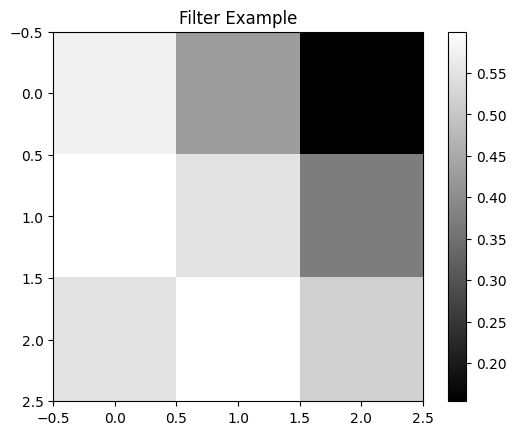

In [10]:
datamodule = UniformFiltersDataModule(num_samples_per_angle=100)
datamodule.setup()
filter_example = datamodule.train_dataloader().dataset[0][0].reshape(3,3)

train_loader = datamodule.train_dataloader()
total_examples = len(train_loader.dataset)
print(f"Total training examples: {total_examples}")

plt.imshow(filter_example, cmap='gray')
plt.colorbar()
plt.title('Filter Example')
plt.show()

### Testing that samples from `UniformFiltersDataModule` lie on the Klein bottle

In [49]:
import random
import numpy as np

dataset = datamodule.train_dataloader().dataset
indices = random.sample(range(len(dataset)), 500)
batch = np.array([dataset[i][0].numpy() for i in indices])

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/persim/landscapes/visuals.py:310: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ls[:, 0], ls[:, 1], label=f"$\lambda_{{{depth}}}$", alpha=alpha)
/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/persim/landscapes/visuals.py:469: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(domain, l, label=f"$\lambda_{{{depth}}}$", alpha=alpha)


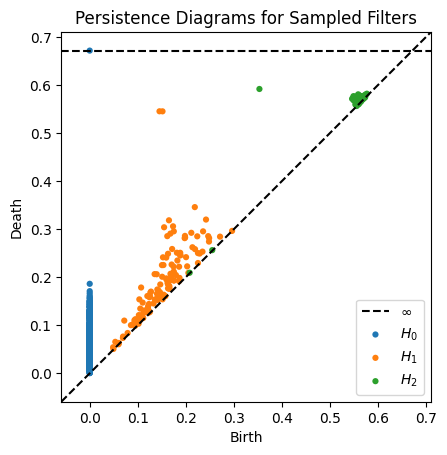

In [50]:
from ripser import ripser
from persim import plot_diagrams

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Sampled Filters')

### Running the model

In [30]:
vae_model = SimpleVAE(input_dim=9, latent_dim=2, hidden_dim=32)
klein_vae_module = KleinVAEModule(model=vae_model, batch_size=64)

/Users/snopoff/Documents/Research/KleinVAE/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [ ]:
trainer = Trainer(devices=1, accelerator="cpu", max_epochs=100, enable_progress_bar=True)
trainer.fit(model=klein_vae_module, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [35]:
trainer.fit(model=klein_vae_module, datamodule=datamodule)


  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SimpleVAE | 3.0 K  | train
--------------------------------------------
3.0 K     Trainable params
0         Non-trainable params
3.0 K     Total params
0.012     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 250/250 [00:01<00:00, 211.87it/s, v_num=3]       

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 250/250 [00:01<00:00, 211.11it/s, v_num=3]


In [36]:
# Retrieve and display the logged metrics after training
metrics = trainer.callback_metrics
print(metrics)

{'train_loss': tensor(187.2677), 'recon_loss': tensor(185.1445), 'kl_div': tensor(2.1232), 'val_loss': tensor(188.1371), 'val_recon_loss': tensor(186.0824), 'val_kl_div': tensor(2.0547)}


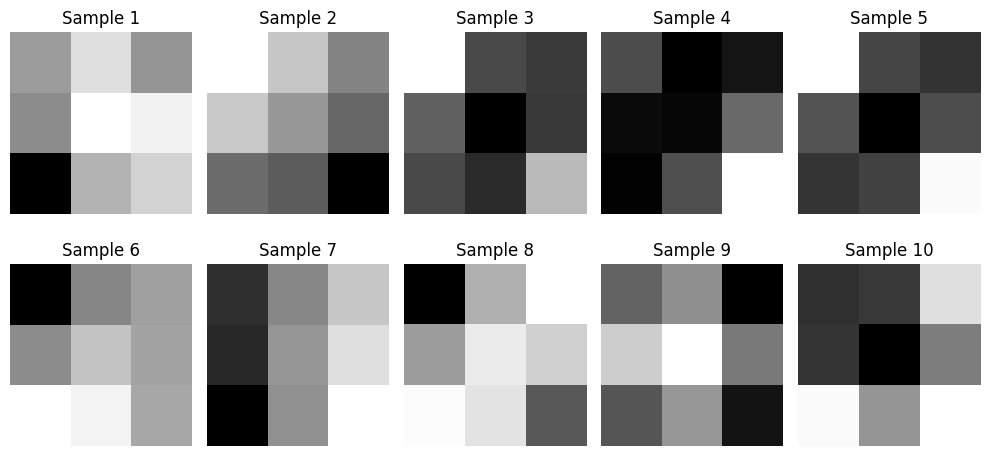

In [37]:
samples = klein_vae_module.sample(num_samples=10)
filters_from_decoder = klein_vae_module.model.decode(samples).reshape(-1, 3, 3)

plt.figure(figsize=(10, 5))
for i, filter_img in enumerate(filters_from_decoder):
    plt.subplot(2, 5, i + 1)
    plt.imshow(filter_img.detach().cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'Sample {i+1}')
plt.tight_layout()
plt.show()

### Testing that decoded samples also lie on the Klein bottle

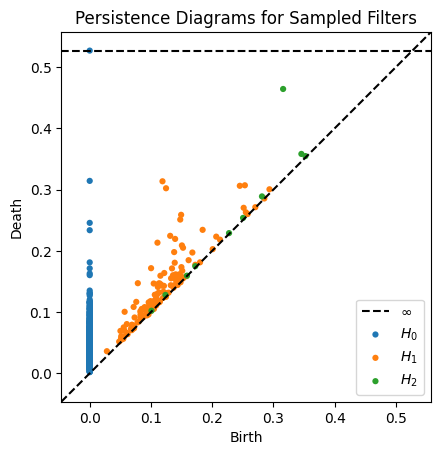

In [58]:
samples = klein_vae_module.sample(num_samples=500)
decoded = klein_vae_module.model.decode(samples).detach().cpu().numpy()
batch = decoded

diagrams = ripser(batch, maxdim=2)['dgms']
plot_diagrams(diagrams, show=True, title='Persistence Diagrams for Sampled Filters')